In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import numpy as np

In [ ]:
path = "data/StudentPerformanceFactors.csv"
df = pd.read_csv(path, sep=',', encoding='ISO-8859-1')

engine = create_engine("sqlite:///data/students.sqlite")
df.to_sql("students", engine, index=False, if_exists="replace")

6607

In [ ]:
path_salary = "data/salary/Salary_Data.csv"
s_df = pd.read_csv(path_salary, sep=',', encoding='ISO-8859-1')

engine2 = create_engine("sqlite:///data/salary.sqlite")
s_df = s_df.rename(columns={"ï»¿Age": "Age", "Education Level":"Education_Level",
                                "Job Title":"Job", "Years of Experience":"Years_of_Experience"})

s_df.to_sql("salary", engine2, index=False, if_exists="replace")


6704

### Distribution of sleep hours from students

This histogram shows the distribution of sleep hours among students.
Each bar represents a specific number of hours slept per night, and the bar’s height indicates how many students reported sleeping that amount.

The x-axis represents the number of hours of sleep.

The y-axis represents the number of students for each number of hours.

This visualization allows us to identify common sleep patterns between students.

Text(0.5, 0, 'Number of hours slept')

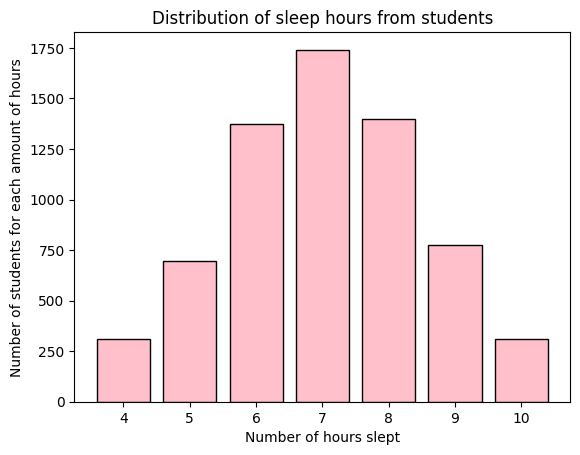

In [ ]:
sleep_hours = pd.read_sql("SELECT Sleep_Hours FROM students", engine)

bins = np.arange(sleep_hours['Sleep_Hours'].min() - 0.5, 
                 sleep_hours['Sleep_Hours'].max() + 1.5, 1)


plt.hist(sleep_hours, bins=bins,  rwidth=0.8, edgecolor="black", color="pink")
plt.title("Distribution of sleep hours from students")
plt.ylabel("Number of students for each amount of hours")
plt.xlabel("Number of hours slept")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
df = df.dropna()
df.to_sql("students", engine, index=True, if_exists='replace')

6378

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6378 non-null   int64 
 1   Attendance                  6378 non-null   int64 
 2   Parental_Involvement        6378 non-null   object
 3   Access_to_Resources         6378 non-null   object
 4   Extracurricular_Activities  6378 non-null   object
 5   Sleep_Hours                 6378 non-null   int64 
 6   Previous_Scores             6378 non-null   int64 
 7   Motivation_Level            6378 non-null   object
 8   Internet_Access             6378 non-null   object
 9   Tutoring_Sessions           6378 non-null   int64 
 10  Family_Income               6378 non-null   object
 11  Teacher_Quality             6378 non-null   object
 12  School_Type                 6378 non-null   object
 13  Peer_Influence              6378 non-null   object
 1

### Motivation Levels with High Parental Involvement

This pie chart shows the distribution of student motivation levels among those whose parents have high involvement in their education.
Each slice represents a motivation category (High, Medium, Low), with its percentage displayed on the chart.

,freq,Motivation_Level
0,936,Medium
1,553,Low
2,347,High


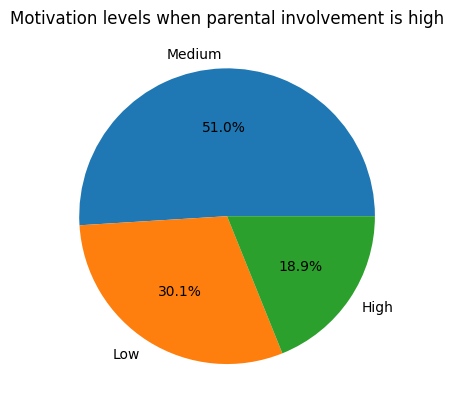

In [ ]:
high_involvement = pd.read_sql("""SELECT count(*) AS freq, Motivation_Level FROM (
                               SELECT * FROM students
                               WHERE Parental_Involvement = 'High'
                               ) GROUP BY Motivation_Level
                               ORDER BY Motivation_Level DESC""", engine)


plt.pie(high_involvement['freq'], labels=high_involvement['Motivation_Level'], autopct='%1.1f%%')
plt.title("Motivation levels when parental involvement is high")
high_involvement.head()

### Motivation Levels with Medium Parental Involvement

This pie chart shows the motivation distribution among students whose parents demonstrate medium involvement.
By comparing this visualization with the previous one, we can observe potential trends — for instance, whether moderate parental support sustains or reduces motivation levels compared to high involvement.

This analysis helps identify whether greater parental support correlates with higher motivation in students.

,freq,Motivation_Level
0,1636,Medium
1,956,Low
2,659,High


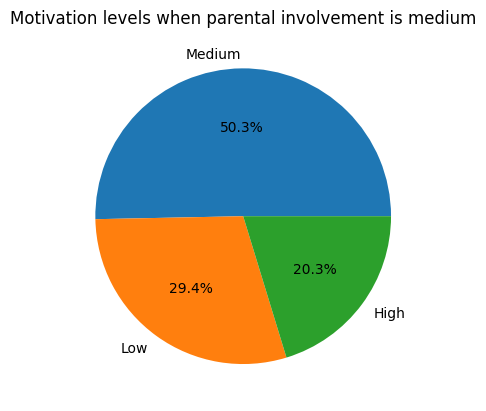

In [ ]:
medium_involvement = pd.read_sql("""SELECT count(*) AS freq, Motivation_Level FROM (
                               SELECT * FROM students
                               WHERE Parental_Involvement = 'Medium'
                               ) GROUP BY Motivation_Level
                               ORDER BY Motivation_Level DESC""", engine)

plt.pie(medium_involvement['freq'], labels=medium_involvement['Motivation_Level'], autopct='%1.1f%%')
plt.title("Motivation levels when parental involvement is medium")
medium_involvement.head()

### Motivation Levels with Low Parental Involvement

This graphic shows the distribuition of movtivation levels between students whose parents have low involvement in their education.
The comparison between the this and the last two graphics provides insights into how family participation may influence a student’s attitude toward studying.

,freq,Motivation_Level
0,665,Medium
1,355,Low
2,271,High


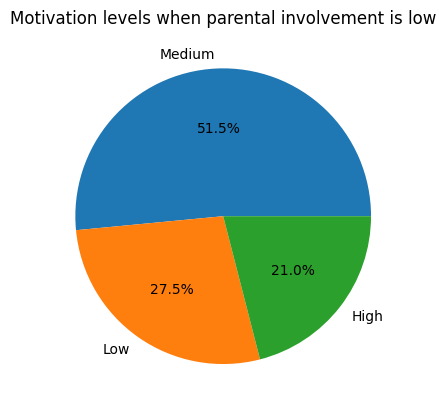

In [ ]:
low_involvement = pd.read_sql("""SELECT count(*) AS freq, Motivation_Level FROM (
                               SELECT * FROM students
                               WHERE Parental_Involvement = 'Low'
                               ) GROUP BY Motivation_Level
                               ORDER BY Motivation_Level DESC""", engine)

plt.pie(low_involvement['freq'], labels=low_involvement['Motivation_Level'], autopct='%1.1f%%')
plt.title("Motivation levels when parental involvement is low")
low_involvement.head()

In [ ]:
high_involvement = high_involvement[high_involvement['freq'] == high_involvement['freq'].max()]
medium_involvement = medium_involvement[medium_involvement['freq'] == medium_involvement['freq'].max()]
low_involvement = low_involvement[low_involvement['freq'] == low_involvement['freq'].max()]

aux = []
aux.append(high_involvement)
aux.append(medium_involvement)
aux.append(low_involvement)
combination = pd.concat(aux, ignore_index=True)
combination.head(2000)

,freq,Motivation_Level
0,936,Medium
1,1636,Medium
2,665,Medium
